# 分布式训练监测

| 指标名                              | 含义               |
| :------------------------------- | :--------------- |
| `distributed/grad_norm_max_diff` | <font color='red'>各节点梯度范数最大差异 </font>     |
| `distributed/loss_max_diff`      | 各节点损失最大差异        |
| `distributed/drop_step_count`    | 因梯度异常被熔断的 step 数 |

## 诊断价值：
grad_norm_max_diff > 1e-5 → <font color='red'>分布式同步可能有问题（如 NCCL 通信故障）</font>


# 三大核心指标详解
## distributed/grad_norm_max_diff —— 梯度范数最大差异

### 计算逻辑：



In [1]:
from IPython.display import Image

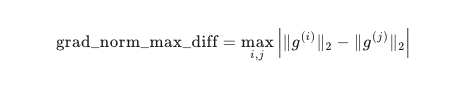

In [2]:
Image(filename='./Image/grad_norm_max_diff.png')

- 其中 g^{(i)}是第 i  个 GPU/节点上的梯度。
### 理论预期：
- 在数据并行（DP）或分布式数据并行（DDP）中，所有节点处理的数据分布相同，梯度经过 all_reduce 平均后，各节点的梯度范数应该完全一致（差异接近机器精度，约 $10^{−7}$ ）。

### 实际容忍阈值：
|      差异范围     | 状态                                              |
| :-----------: | :---------------------------------------------- |
|    `< 1e-6`   | ✅ 完美同步                                          |
| `1e-6 ~ 1e-5` | ⚠️ 轻微数值误差，可接受                                   |
|    `> 1e-5`   | 🚨 **分布式同步异常**，可能存在 NCCL 通信故障、数据加载不一致、或某些节点计算错误 |


## distributed/loss_max_diff —— 损失最大差异

### 计算逻辑


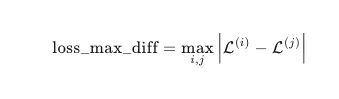

In [3]:
Image(filename='./Image/loss_max_diff.png')

### 诊断价值：
- 在 forward 阶段，如果各节点的输入数据不同（如数据加载器未正确 shard），loss 会先出现分歧
- 如果 loss_max_diff 很大但 grad_norm_max_diff 正常：可能是数据分布不均，但梯度 all_reduce 后仍一致
- 如果两者都大：分布式同步彻底失效

## distributed/drop_step_count —— 熔断 step 计数
含义：整个训练过程中，因梯度异常（如范数超过熔断阈值、NCCL 超时、数值非法）而被丢弃的 step 总数。
诊断价值：
- = 0：训练稳定
- < 1% 总步数：偶发异常，可接受
- > 5%：🚨 训练严重不稳定，必须排查硬件/通信/数据问题

# 分布式一致性校验原理
## 为什么梯度应该一致？
在 DDP 中，PyTorch 的 DistributedDataParallel 会在 backward 时自动 all_reduce 梯度：

In [ ]:
# DDP 内部逻辑（简化）
for param in model.parameters():
    if param.grad is not None:
        dist.all_reduce(param.grad, op=dist.ReduceOp.AVG)  # 平均

所有节点最终持有的梯度是全局平均后的相同值，因此：
- 各节点的 grad_norm 应该完全相同
- 各节点的 loss（在 forward 后、all_reduce 前）可能有差异，但 backward 后梯度应一致

## 差异的来源

| 根因                 | 机制                            |
| :----------------- | :---------------------------- |
| **NCCL 通信故障**      | 某些节点的 all\_reduce 未完成或数据损坏    |
| **数据加载不一致**        | 各节点读取了不同的数据 shard（如 seed 未同步） |
| **Dropout/随机层未同步** | 各节点随机种子不同，forward 输出不同        |
| **混合精度溢出**         | 某些节点 FP16 溢出但其他节点没有           |
| **梯度裁剪不同步**        | 各节点独立裁剪，裁剪阈值/行为不一致            |


# 完整分布式监控类


In [ ]:
import torch
import torch.distributed as dist
import torch.nn as nn
import time
from collections import defaultdict

class DistributedMonitor:
    """
    verl 风格的分布式训练监测器
    支持：梯度一致性校验、损失一致性校验、熔断计数、NCCL 健康检测
    """
    def __init__(self, world_size, rank, grad_norm_tolerance=1e-5, 
                 loss_tolerance=1e-3, grad_breaker=1000.0):
        self.world_size = world_size
        self.rank = rank
        self.grad_tol = grad_norm_tolerance
        self.loss_tol = loss_tolerance
        self.grad_breaker = grad_breaker
        
        self.drop_count = 0
        self.history = defaultdict(list)
        
        # 初始化分布式（如果尚未初始化）
        if not dist.is_initialized():
            dist.init_process_group('nccl', rank=rank, world_size=world_size)
    
    def _all_gather_scalar(self, local_value):
        """收集所有节点的标量值"""
        if self.world_size == 1:
            return [local_value]
        
        tensor = torch.tensor([local_value], dtype=torch.float32, device='cuda')
        gathered = [torch.zeros(1, device='cuda') for _ in range(self.world_size)]
        dist.all_gather(gathered, tensor)
        return [t.item() for t in gathered]
    
    def check_gradient_consistency(self, model):
        """
        校验各节点梯度范数的一致性
        返回：是否一致、最大差异、各节点范数列表
        """
        # 计算本地梯度范数
        local_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                local_norm += p.grad.data.norm(2).item() ** 2
        local_norm = local_norm ** 0.5
        
        # 收集所有节点的范数
        all_norms = self._all_gather_scalar(local_norm)
        
        # 计算最大差异
        max_diff = max(all_norms) - min(all_norms)
        is_consistent = max_diff < self.grad_tol
        
        # 记录
        self.history['grad_norm_max_diff'].append(max_diff)
        self.history['grad_norms_all'].append(all_norms)
        
        return {
            'local_norm': local_norm,
            'all_norms': all_norms,
            'max_diff': max_diff,
            'is_consistent': is_consistent,
        }
    
    def check_loss_consistency(self, local_loss):
        """
        校验各节点损失的一致性
        """
        all_losses = self._all_gather_scalar(local_loss)
        max_diff = max(all_losses) - min(all_losses)
        is_consistent = max_diff < self.loss_tol
        
        self.history['loss_max_diff'].append(max_diff)
        self.history['losses_all'].append(all_losses)
        
        return {
            'local_loss': local_loss,
            'all_losses': all_losses,
            'max_diff': max_diff,
            'is_consistent': is_consistent,
        }
    
    def check_grad_breaker(self, model):
        """
        梯度熔断检查 + 分布式同步
        如果本地梯度异常，标记该 step 为异常
        """
        local_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                local_norm += p.grad.data.norm(2).item() ** 2
        local_norm = local_norm ** 0.5
        
        # 收集所有节点的"是否异常"标记
        is_local_abnormal = local_norm > self.grad_breaker
        abnormal_flags = self._all_gather_scalar(1.0 if is_local_abnormal else 0.0)
        
        # 只要有一个节点异常，全局熔断（保证所有节点同步跳过）
        should_drop = any(f > 0.5 for f in abnormal_flags)
        
        if should_drop:
            self.drop_count += 1
        
        self.history['drop_step_count'].append(self.drop_count)
        
        return {
            'should_drop': should_drop,
            'abnormal_nodes': [i for i, f in enumerate(abnormal_flags) if f > 0.5],
            'total_drops': self.drop_count,
        }
    
    def diagnose(self, step):
        """打印分布式诊断报告"""
        if self.rank != 0:
            return  # 只在 rank 0 打印
        
        print(f"\n{'='*70}")
        print(f"Step {step} 分布式训练诊断 (World Size: {self.world_size})")
        print(f"{'='*70}")
        
        # 梯度一致性
        if self.history['grad_norm_max_diff']:
            gdiff = self.history['grad_norm_max_diff'][-1]
            status = "✅" if gdiff < self.grad_tol else "🚨"
            print(f"【梯度一致性】max_diff={gdiff:.2e} {status}")
            
            if gdiff > self.grad_tol:
                print(f"   🚨 警告：梯度范数差异超过阈值 {self.grad_tol}！")
                print(f"      可能原因：NCCL 通信故障、数据加载不一致、随机层未同步")
                print(f"      修复建议：")
                print(f"        1. 检查 NCCL 日志：NCCL_DEBUG=INFO")
                print(f"        2. 确认数据加载器 seed 同步")
                print(f"        3. 检查 Dropout 等随机层是否使用分布式同步种子")
                print(f"        4. 尝试重新初始化进程组")
            
            # 打印各节点范数（用于调试）
            if 'grad_norms_all' in self.history and self.history['grad_norms_all']:
                norms = self.history['grad_norms_all'][-1]
                print(f"      各节点范数: {[f'{n:.4f}' for n in norms]}")
        
        # 损失一致性
        if self.history['loss_max_diff']:
            ldiff = self.history['loss_max_diff'][-1]
            status = "✅" if ldiff < self.loss_tol else "⚠️"
            print(f"\n【损失一致性】max_diff={ldiff:.4f} {status}")
            
            if ldiff > self.loss_tol:
                print(f"   ⚠️ 警告：损失差异较大，数据分布可能不均")
                if 'losses_all' in self.history and self.history['losses_all']:
                    losses = self.history['losses_all'][-1]
                    print(f"      各节点 loss: {[f'{l:.4f}' for l in losses]}")
        
        # 熔断统计
        print(f"\n【熔断统计】累计丢弃 step: {self.drop_count}")
        if self.drop_count > 0:
            total_steps = len(self.history['grad_norm_max_diff'])
            drop_rate = self.drop_count / max(total_steps, 1)
            status = "✅" if drop_rate < 0.01 else "⚠️" if drop_rate < 0.05 else "🚨"
            print(f"            丢弃率: {drop_rate*100:.2f}% {status}")
            if drop_rate > 0.05:
                print(f"   🚨 警告：丢弃率超过 5%，训练严重不稳定！")
        
        print(f"{'='*70}")
    
    def barrier_with_timeout(self, timeout_sec=30):
        """
        带超时的同步屏障，检测 NCCL 死锁
        """
        try:
            dist.barrier()
            return True
        except Exception as e:
            print(f"🚨 Rank {self.rank}: Barrier timeout! NCCL 可能死锁: {e}")
            return False


# ==================== 使用示例 ====================

def simulate_distributed_training():
    """
    模拟分布式训练环境（单进程模拟多节点）
    """
    print("=" * 70)
    print("模拟分布式训练监测")
    print("=" * 70)
    
    world_size = 4  # 模拟 4 卡
    results = []
    
    # 模拟每个节点的训练
    for rank in range(world_size):
        # 模拟模型
        model = nn.Linear(256, 128)
        model.zero_grad()
        
        # 模拟前向 + 反向
        x = torch.randn(8, 256)
        out = model(x)
        loss = out.mean()
        loss.backward()
        
        # 模拟梯度（正常情况应该一致，这里人为制造差异）
        if rank == 2:  # 模拟第 2 卡异常
            for p in model.parameters():
                if p.grad is not None:
                    p.grad *= 1.5  # 梯度异常放大
        
        # 记录本地信息
        local_norm = sum(p.grad.norm(2).item()**2 for p in model.parameters() if p.grad is not None) ** 0.5
        results.append({
            'rank': rank,
            'grad_norm': local_norm,
            'loss': loss.item(),
        })
    
    # 模拟分布式校验（在真实环境中由 monitor 自动完成）
    all_norms = [r['grad_norm'] for r in results]
    all_losses = [r['loss'] for r in results]
    
    grad_diff = max(all_norms) - min(all_norms)
    loss_diff = max(all_losses) - min(all_losses)
    
    print(f"\n模拟 4 卡训练结果：")
    for r in results:
        print(f"  Rank {r['rank']}: grad_norm={r['grad_norm']:.4f}, loss={r['loss']:.4f}")
    
    print(f"\n【校验结果】")
    print(f"  梯度范数最大差异: {grad_diff:.4f}")
    if grad_diff > 1e-5:
        print(f"  🚨 异常！Rank 2 的梯度明显偏大，可能存在 NCCL 通信问题或数据不一致")
    else:
        print(f"  ✅ 梯度一致")
    
    print(f"  损失最大差异: {loss_diff:.6f}")
    if loss_diff > 1e-3:
        print(f"  ⚠️ 损失差异较大")
    else:
        print(f"  ✅ 损失一致")

# 运行模拟
simulate_distributed_training()

# 真实分布式环境示例（伪代码）
print("\n" + "=" * 70)
print("真实分布式环境使用示例（伪代码）")
print("=" * 70)

distributed_code = '''
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP

# 初始化
dist.init_process_group('nccl')
rank = dist.get_rank()
world_size = dist.get_world_size()

# 创建监控器
monitor = DistributedMonitor(
    world_size=world_size,
    rank=rank,
    grad_norm_tolerance=1e-5,
    grad_breaker=1000.0,
)

# 训练循环
for step in range(total_steps):
    # 1. 前向
    outputs = model(inputs)
    loss = compute_loss(outputs)
    
    # 2. 反向
    optimizer.zero_grad()
    loss.backward()
    
    # 3. 分布式校验（关键！）
    grad_info = monitor.check_gradient_consistency(model)
    loss_info = monitor.check_loss_consistency(loss.item())
    breaker_info = monitor.check_grad_breaker(model)
    
    # 4. 如果任何节点异常，全局跳过
    if breaker_info['should_drop']:
        optimizer.zero_grad()
        if rank == 0:
            print(f"Step {step}: 全局熔断，跳过更新")
        continue
    
    # 5. 如果梯度不一致，报警
    if not grad_info['is_consistent'] and rank == 0:
        print(f"Step {step}: 梯度不一致！max_diff={grad_info['max_diff']:.2e}")
    
    # 6. 正常更新
    optimizer.step()
    
    # 7. 定期诊断
    if step % 10 == 0:
        monitor.diagnose(step)
'''

print(distributed_code)

# NCCL 通信故障排查指南

当 grad_norm_max_diff > 1e-5 时，按以下顺序排查：

##  检查 NCCL 健康状态

In [ ]:
# 启动训练时开启 NCCL 调试日志
NCCL_DEBUG=INFO NCCL_DEBUG_SUBSYS=ALL python train.py

# 检查是否有超时或错误
# 常见错误：NCCL_TIMEOUT, NCCL_COMM_ABORT

## 检查数据加载一致性

In [ ]:
# 确保所有节点使用相同的随机种子
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)  # 关键！所有 GPU 同步

set_seed(42 + epoch)  # 每个 epoch 同步更新

## 检查随机层同步

In [ ]:
# Dropout、BatchNorm 等层需要同步
# 使用 torch.nn.SyncBatchNorm 替代 BatchNorm
model = nn.SyncBatchNorm.convert_sync_batchnorm(model)

## 检查梯度 all_reduce 是否完成

In [ ]:
# 手动验证 all_reduce
test_tensor = torch.ones(1, device='cuda') * rank
dist.all_reduce(test_tensor, op=dist.ReduceOp.SUM)
expected = sum(range(world_size))
assert test_tensor.item() == expected, "all_reduce 失败！"

# 分布式训练最佳实践

In [ ]:
| 实践                                | 作用                       |
| :-------------------------------- | :----------------------- |
| **每步校验梯度一致性**                     | 及时发现 NCCL 静默错误           |
| **全局熔断而非本地熔断**                    | 避免某些节点跳过更新导致参数分歧         |
| **使用 `torch.cuda.synchronize()`** | 确保计时和内存统计准确              |
| **设置 `NCCL_IB_TIMEOUT`**          | 防止 InfiniBand 网络超时导致训练中断 |
| **定期 `dist.barrier()` 健康检查**      | 检测节点是否掉队                 |


# 一句话总结
分布式监测是 RL 训练的"分布式心电图"：梯度一致性确保所有节点"心跳同步"，损失一致性确保所有节点"看到相同的数据"，熔断计数确保异常不会扩散。当 grad_norm_max_diff > 1e-5 时，意味着分布式训练的根基已动摇——必须立即检查 NCCL 通信、数据加载和随机种子同步，否则模型将在各节点上分裂成不同的策略。